In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from scipy.signal import find_peaks
from scipy.signal import peak_widths

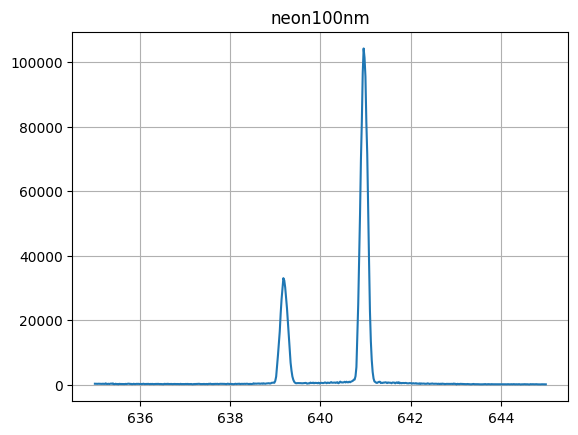

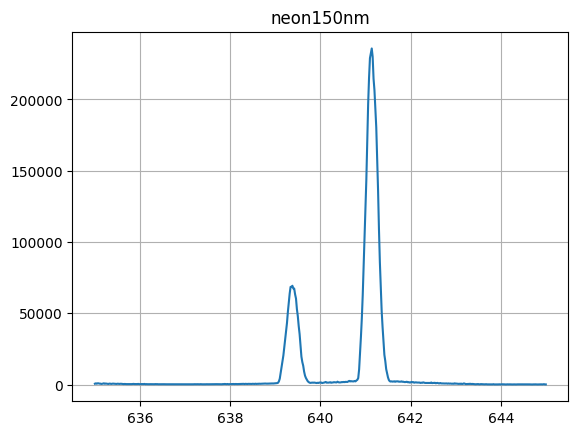

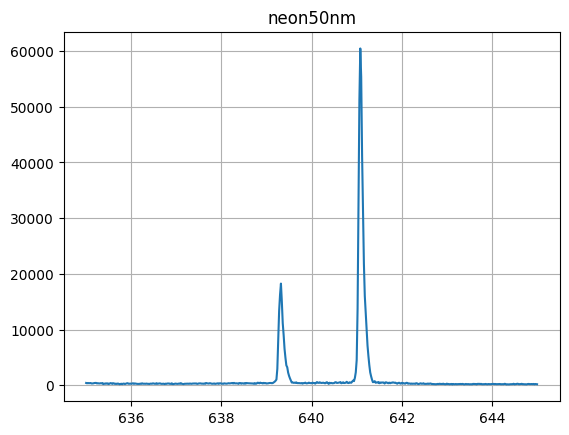

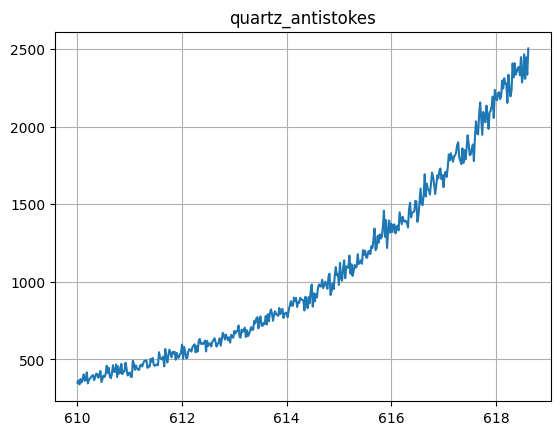

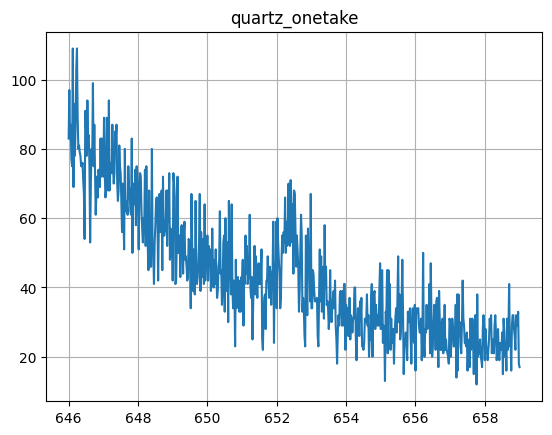

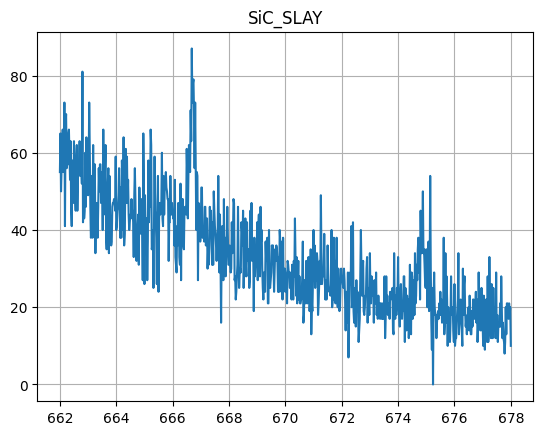

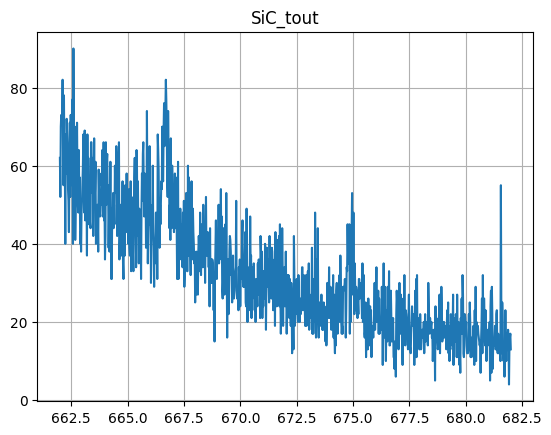

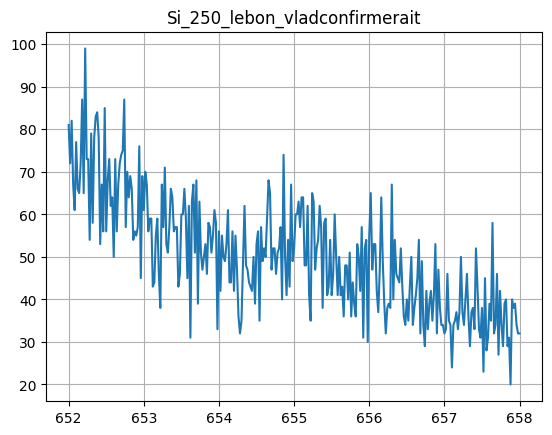

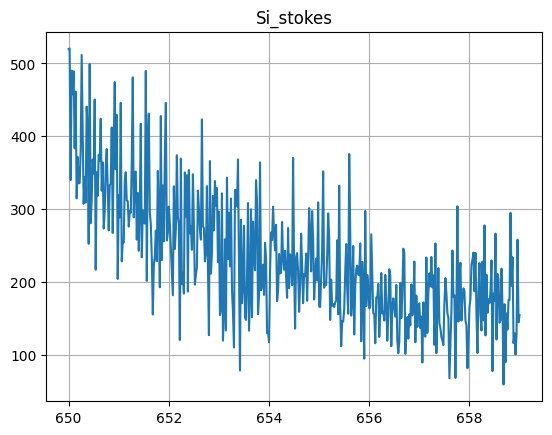

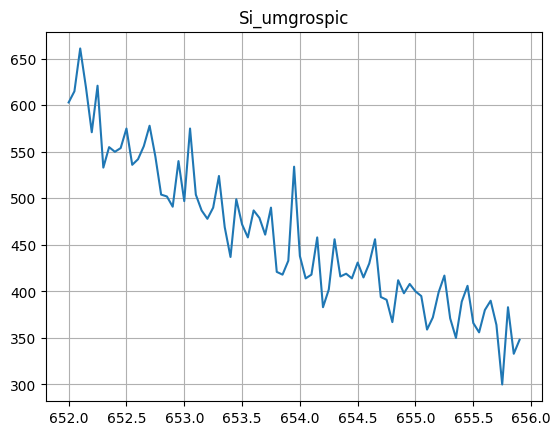

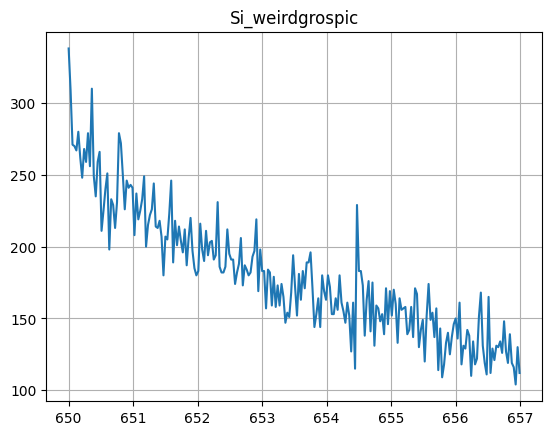

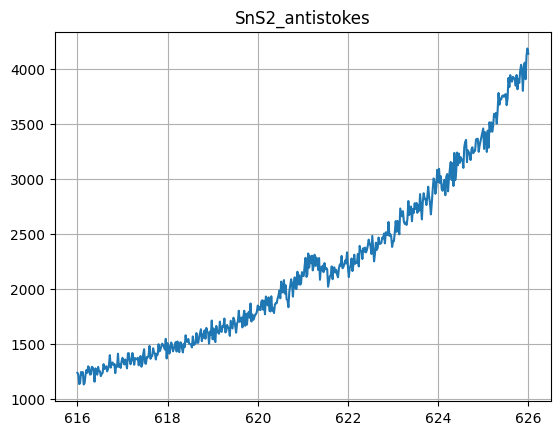

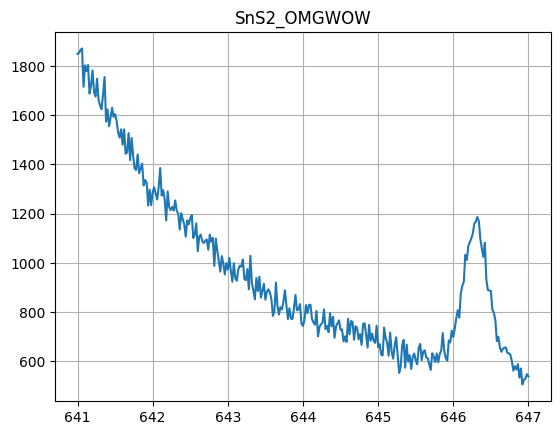

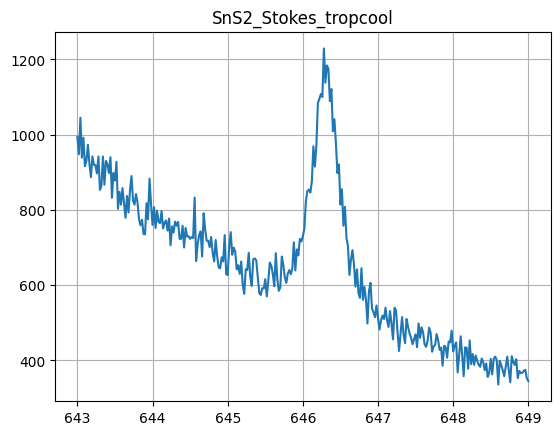

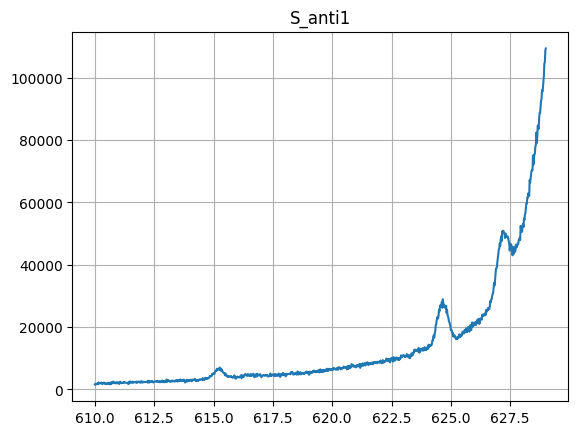

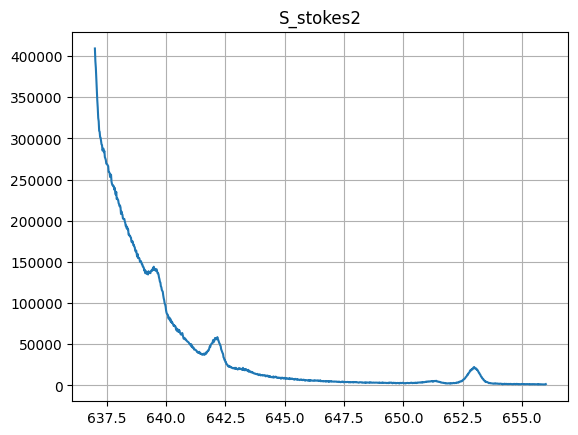

In [17]:
donnees = os.listdir('donnees//RAM_AR_NS')
donnees[0]
for i in donnees:
    #plt.figure(figsize=(4,4))
    spectre = np.loadtxt(f'donnees//RAM_AR_NS//{i}')
    plt.plot(spectre[:,0], spectre[:,1])
    plt.title(f'{i}')
    plt.grid()
    plt.show()

[ 3.07361364e+02 -2.33076227e-01  6.09680841e+02]
[5.27472626e+01 1.03562207e-01 6.49996559e+02]
[5.22206838e+01 7.75431645e-02 6.63231781e+02]


C:\Users\simar\AppData\Local\Temp\ipykernel_31632\2269120483.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\simar\AppData\Local\Temp\ipykernel_31632\2269120483.py:5: RuntimeWarning: overflow encountered in exp
  return a*np.exp(-(x-f)*b)


[6.28063536e+01 7.31337503e-02 6.61736836e+02]
[6.12833945e+01 1.16646344e-01 6.53128883e+02]
[4.43871091e+02 1.08728167e-01 6.48249243e+02]
[5.55587804e+02 1.42681103e-01 6.52517962e+02]
[3.24269411e+02 1.11236019e-01 6.48003739e+02]
[ 9.45774877e+02 -1.24554951e-01  6.14745196e+02]
[2.07613087e+03 1.91854291e-01 6.39679774e+02]
[7.55301139e+02 1.29538107e-01 6.44683625e+02]
[ 6.63196809e+02 -3.86561062e-01  6.16347208e+02]
[2.30495835e+05 4.40824392e-01 6.37942793e+02]


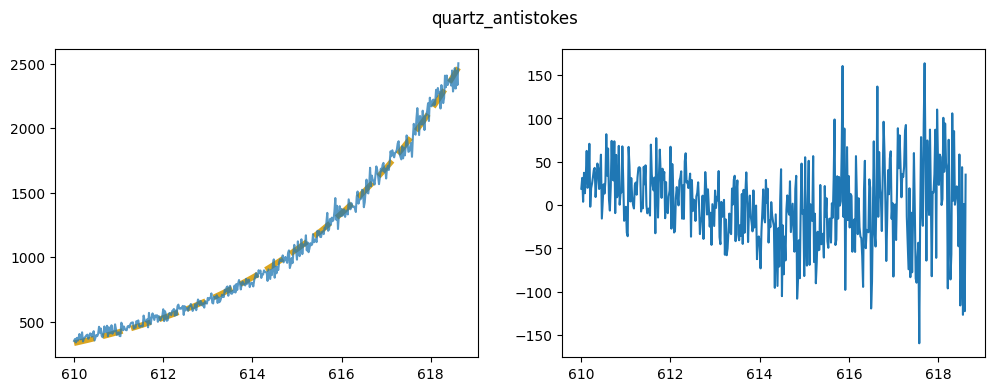

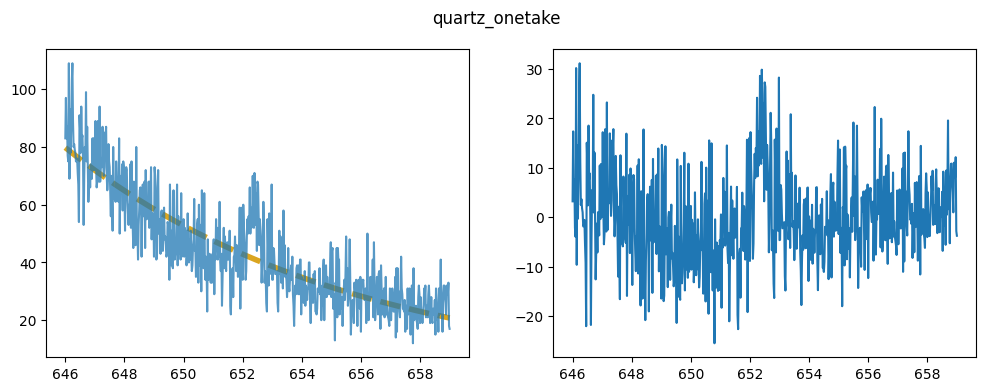

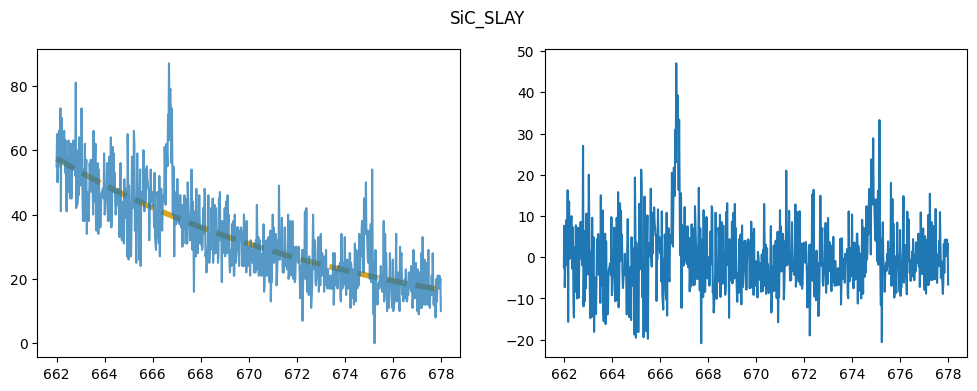

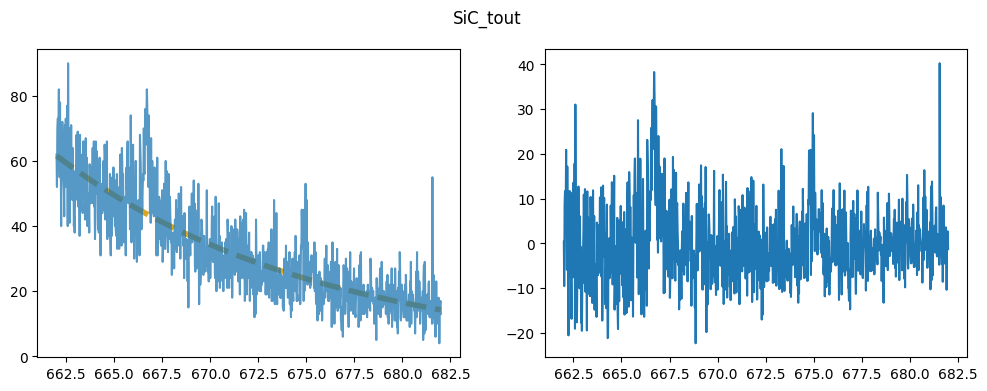

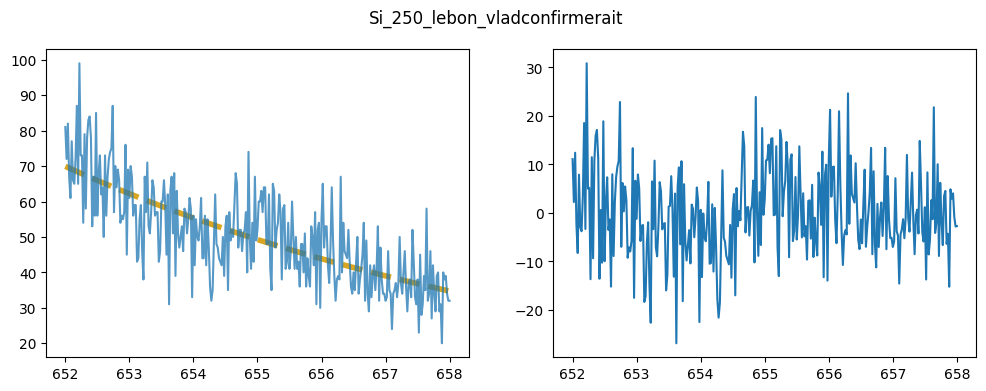

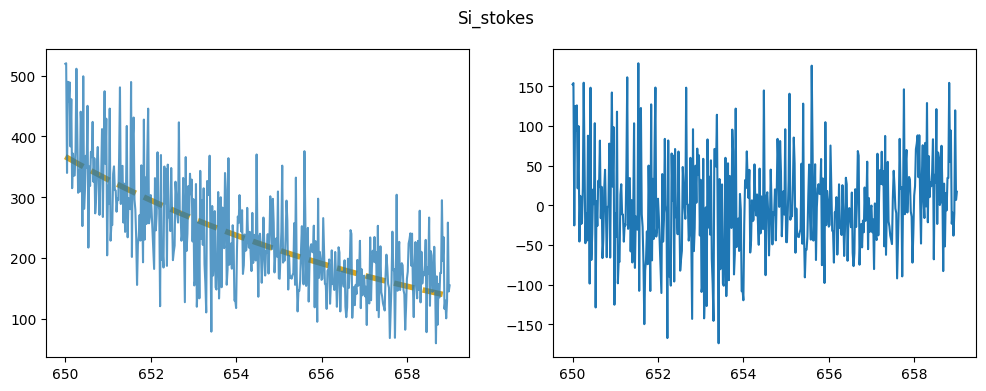

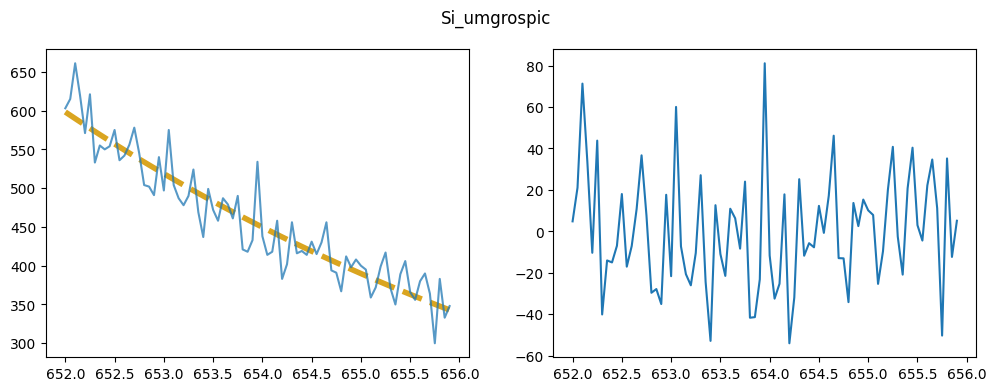

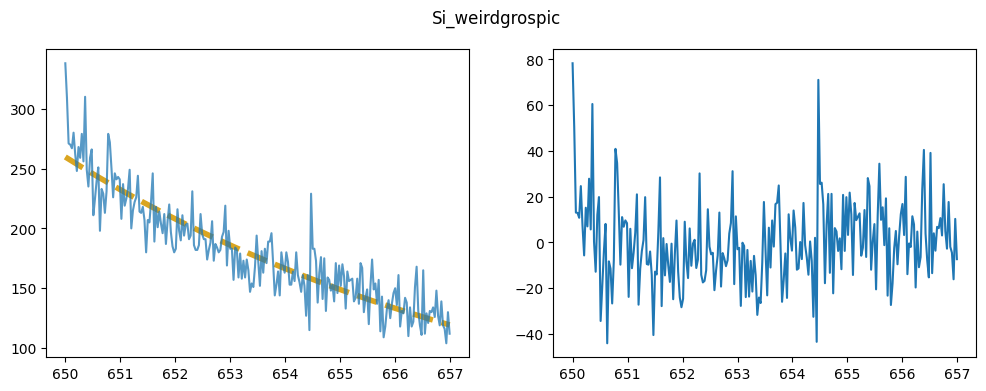

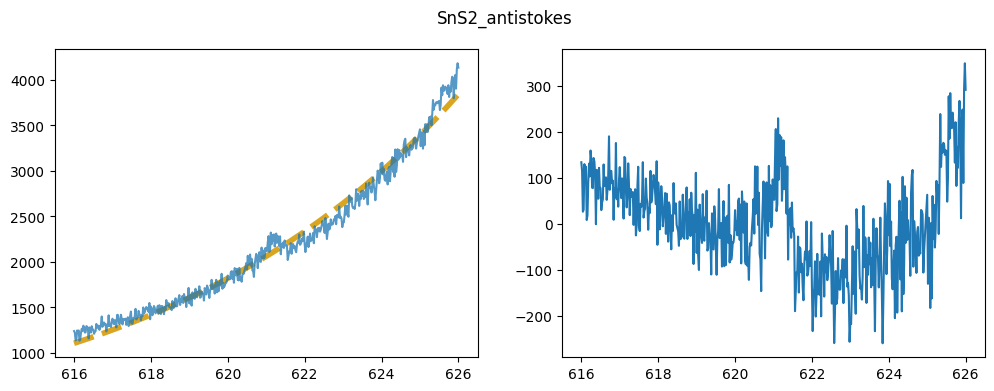

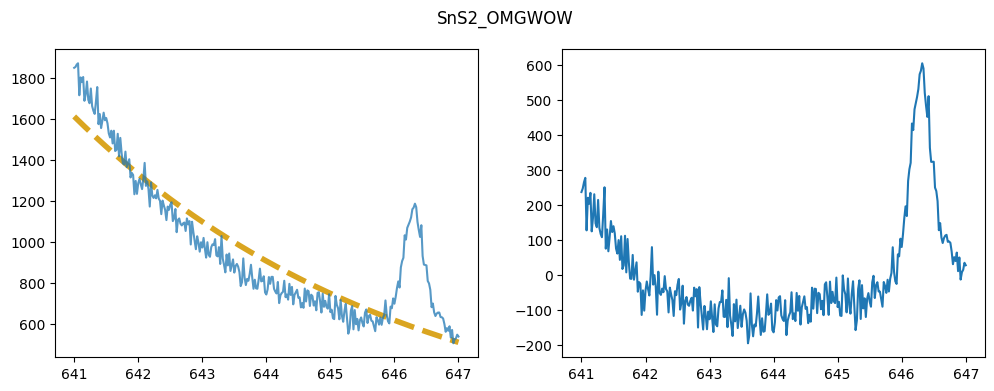

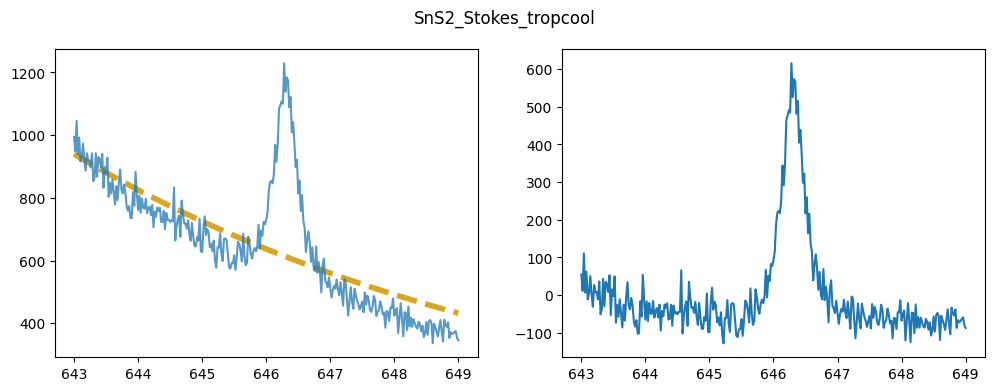

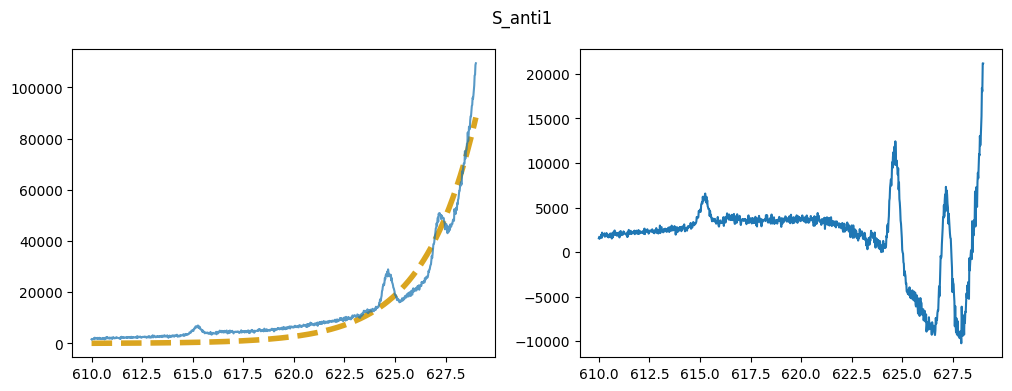

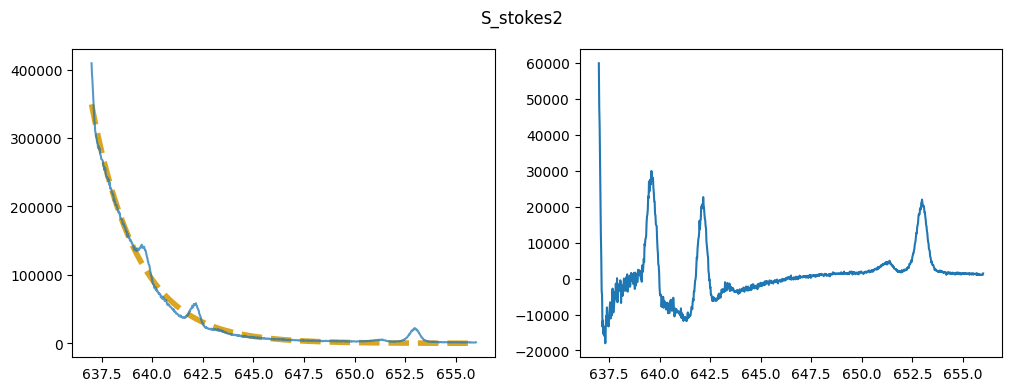

In [18]:
def courbe(x,a,b,c,d):
    return a*np.exp(-x*b)+c*np.exp(-x**2*d)

def exp(x,a,b,f):
    return a*np.exp(-(x-f)*b)

for i in donnees:
    spectre = np.loadtxt(f'donnees//RAM_AR_NS//{i}')
    if 'neon' in i:
        continue
    popt, pcov = curve_fit(exp, spectre[:,0], spectre[:,1],p0=[spectre[0,1],1,spectre[0,0]])
    print(popt)
    fig, ax = plt.subplots(1,2,figsize=(12,4))
    ax[0].plot(spectre[:,0], exp(spectre[:,0], *popt),linestyle='--',linewidth=4,color='goldenrod')
    ax[0].plot(spectre[:,0], spectre[:,1],alpha=.75)
    
    ax[1].plot(spectre[:,0], spectre[:,1]-exp(spectre[:,0], *popt))
    fig.suptitle(f'{i}')
    fig.show()

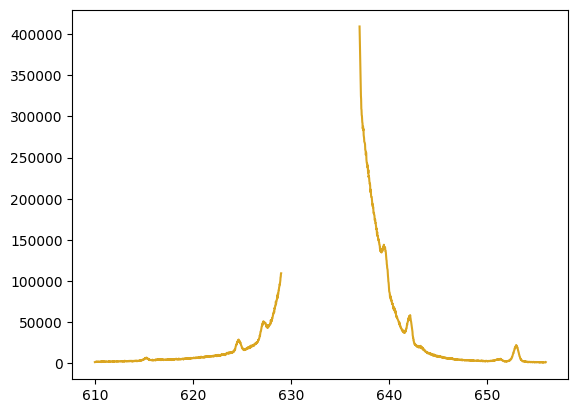

In [32]:
##Pour le Soufre##

for i in donnees:
    spectre = np.loadtxt(f'donnees//RAM_AR_NS//{i}')
    if 'S_' in i:
        plt.plot(spectre[:,0], spectre[:,1],color='goldenrod')
    plt.savefig('soufre')


(array([9.66562294, 9.18338633]), array([16720.39, 52177.44]), array([205.02365328, 293.95556836]), array([214.68927622, 303.13895469]))
(array([15.41279413, 14.8003169 ]), array([ 35157.   , 117921.905]), array([211.61979167, 299.8679846 ]), array([227.0325858, 314.6683015]))
(array([5.67509182, 5.23132965]), array([ 9252.82, 30308.12]), array([213.22194988, 301.87757904]), array([218.8970417 , 307.10890869]))


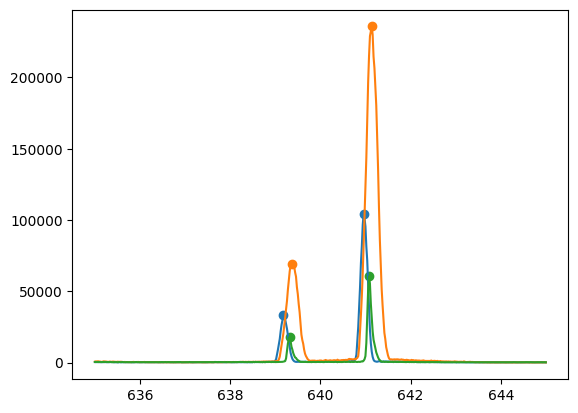

In [61]:
#pour l'étalonnage
for i in donnees:
    spectre = np.loadtxt(f'donnees//RAM_AR_NS//{i}')
    if 'neon' in i:
        peaks = find_peaks(spectre[:,1],height=10000,distance=5)
        FWHMs = peak_widths(spectre[:,1],peaks[0])

        plt.plot(spectre[:,0], spectre[:,1])
        plt.scatter(spectre[list(peaks[0]),0],peaks[1]['peak_heights'])
        
        print(FWHMs)